# 04b: Experiment: PANNs CNN14

Replaces AST with CNN14: a 14-layer CNN pretrained on AudioSet (Kong et al. 2020). Purely convolutional, no attention mechanism. Strong at detecting local spectral patterns, well-suited for crackles (short bursts) and wheezes (sustained bands).

**Baseline to beat**: Se=69.87%, Sp=67.81%, Score=68.84%

Config: `configs/cnn14.yaml` (1-epoch smoke test: `cnn14_1epoch.yaml`)

> Note: CNN14 uses a higher learning rate (1e-4) and larger batch size (32) than AST

In [10]:
GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1_0vF1VFxGa1fIQSBkN3o1JJ1B-n-ikOg"
CACHE_FILENAME    = "icbhi_16k_8s.pt"
CACHE_DIR         = "/kaggle/working/icbhi_cache"
SAVE_DIR          = "/kaggle/working/checkpoints/cnn14"
CONFIG_NAME       = "cnn14.yaml"       # change to cnn14_1epoch.yaml to smoke test

In [11]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/safina57/project-deep-learning.git"
REPO_DIR = Path("/kaggle/working/repo")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print(f"project root: {REPO_DIR}")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "librosa", "soundfile", "pyyaml", "gdown", "panns-inference"],
    check=True,
)
print("deps installed")

From https://github.com/safina57/project-deep-learning
   b323171..6cc2b6d  main       -> origin/main


Updating b323171..6cc2b6d
Fast-forward
 src/training/train_loop.py | 10 ++++++++--
 1 file changed, 8 insertions(+), 2 deletions(-)
project root: /kaggle/working/repo
deps installed


In [12]:
import gdown, torch

CACHE_PATH = Path(CACHE_DIR) / CACHE_FILENAME
if not CACHE_PATH.exists():
    Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
    gdown.download_folder(GDRIVE_FOLDER_URL, output=CACHE_DIR, quiet=False)

assert CACHE_PATH.exists()
_probe = torch.load(CACHE_PATH, weights_only=False)
assert "x_val" in _probe, "Cache missing x_val — re-run NB 02."
print(f"splits: train={_probe['x_train'].shape[0]}  val={_probe['x_val'].shape[0]}  test={_probe['x_test'].shape[0]}")
del _probe

splits: train=3260  val=882  test=2756


In [13]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}  {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB")
if not torch.cuda.is_available():
    print("WARNING: no GPU.")

GPU 0: Tesla T4  15.6 GB
GPU 1: Tesla T4  15.6 GB


In [14]:
import yaml
from src.training.train_loop import train

config = yaml.safe_load((REPO_DIR / "configs" / CONFIG_NAME).read_text())
config["save_dir"] = SAVE_DIR
print("config:", config)

results = train(config, cache_path=CACHE_PATH, device=device)

config: {'model_type': 'cnn14', 'lr': 0.0001, 'wd': 0.0001, 'rho': 0.05, 'batch_size': 32, 'epochs': 20, 'seed': 17, 'cache_path': 'data/cache/icbhi_16k_8s.pt', 'save_dir': '/kaggle/working/checkpoints/cnn14', 'label_smoothing': 0.1}
Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
GPU number: 2
using 2 GPUs via DataParallel


epoch 01/20:   0%|          | 0/102 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

[01/20] loss=1.3660  Se=65.71%  Sp=65.59%  Score=65.65%


epoch 02/20:   0%|          | 0/102 [00:00<?, ?it/s]

...

val:   0%|          | 0/7 [00:00<?, ?it/s]

[19/20] loss=0.9154  Se=43.90%  Sp=81.29%  Score=62.59%


epoch 20/20:   0%|          | 0/102 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

[20/20] loss=0.9147  Se=48.83%  Sp=73.44%  Score=61.14%


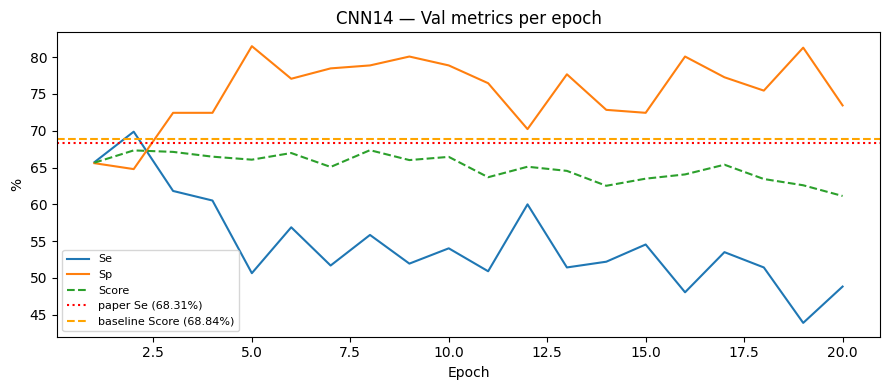

Best val  Se=55.84%  Sp=78.87%  Score=67.36%  (epoch 8)


In [15]:
import matplotlib.pyplot as plt

epochs = [m["epoch"] for m in results["history"]]
se     = [m["se"]    * 100 for m in results["history"]]
sp     = [m["sp"]    * 100 for m in results["history"]]
score  = [m["score"] * 100 for m in results["history"]]

plt.figure(figsize=(9, 4))
plt.plot(epochs, se,    label="Se")
plt.plot(epochs, sp,    label="Sp")
plt.plot(epochs, score, label="Score", linestyle="--")
plt.axhline(68.31, color="red",    linestyle=":",  label="paper Se (68.31%)")
plt.axhline(68.84, color="orange", linestyle="--", label="baseline Score (68.84%)")
plt.xlabel("Epoch"); plt.ylabel("%")
plt.title("CNN14 — Val metrics per epoch")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

best = max(results["history"], key=lambda m: m["score"])
print(f"Best val  Se={best['se']*100:.2f}%  Sp={best['sp']*100:.2f}%  Score={best['score']*100:.2f}%  (epoch {best['epoch']})")

## Final test evaluation

In [17]:
from pathlib import Path                                                                     
                                                                                              
# last.pt was not saved (training ran before this feature was added).                        
# Fall back to the best checkpoint so the comparison still runs.                             
if results["last_checkpoint"] is None or not Path(results["last_checkpoint"]).exists():      
    results["last_checkpoint"] = results["best_checkpoint"]                                  
    print("last.pt not found — using best checkpoint as fallback for last-epoch eval.")

last.pt not found — using best checkpoint as fallback for last-epoch eval.


In [18]:
from src.training.train_loop import evaluate_test
import numpy as np

print("Evaluating best checkpoint vs final epoch...\n")

m_best = evaluate_test(results["best_checkpoint"], CACHE_PATH, config, device)
m_last = evaluate_test(results["last_checkpoint"], CACHE_PATH, config, device)

print(f"{'Checkpoint':<30} {'Se':>7} {'Sp':>7} {'Score':>7}")
print("-" * 55)
print(f"{'best (val Score)  ' + m_best['checkpoint']:<30} {m_best['se']*100:>6.2f}% {m_best['sp']*100:>6.2f}% {m_best['score']*100:>6.2f}%")
print(f"{'last (final epoch) ' + m_last['checkpoint']:<30} {m_last['se']*100:>6.2f}% {m_last['sp']*100:>6.2f}% {m_last['score']*100:>6.2f}%")
print()
print("Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%")
print("AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%")
print("\nConfusion matrix — best checkpoint (rows=true, cols=pred):")
print(np.array(m_best["confusion_matrix"]))
print("\nConfusion matrix — last checkpoint (rows=true, cols=pred):")
print(np.array(m_last["confusion_matrix"]))
m_test = m_best  # used by save cell


Evaluating best checkpoint vs final epoch...

Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
GPU number: 2
Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
GPU number: 2
Checkpoint                          Se      Sp   Score
-------------------------------------------------------
best (val Score)  best_score_epoch08.pt  68.90%  57.69%  63.30%
last (final epoch) best_score_epoch08.pt  68.90%  57.69%  63.30%

Reference paper:   Se=68.31%  Sp=67.89%  Score=68.10%
AST baseline:      Se=69.87%  Sp=67.81%  Score=68.84%

Confusion matrix — best checkpoint (rows=true, cols=pred):
[[911 260 380  28]
 [242 359  28  20]
 [ 94  37 184  70]
 [ 30  13  55  45]]

Confusion matrix — last checkpoint (rows=true, cols=pred):
[[911 260 380  28]
 [242 359  28  20]
 [ 94  37 184  70]
 [ 30  13  55  45]]


In [19]:
import json, shutil
from IPython.display import FileLink, display
from pathlib import Path

save_dir = Path(SAVE_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

results_path = save_dir / "results.json"
results_path.write_text(json.dumps({
    "experiment": config.get("model_type", "ast"),
    "config": config,
    "test_best": m_best,
    "test_last": m_last,
    "best_val": best,
    "history": results["history"],
}, indent=2))

exp = config.get("model_type", "ast")
shutil.copy(results_path, f"/kaggle/working/results_{exp}.json")
if results["best_checkpoint"] and Path(results["best_checkpoint"]).exists():
    shutil.copy(results["best_checkpoint"], f"/kaggle/working/best_checkpoint_{exp}.pt")
if results["last_checkpoint"] and Path(results["last_checkpoint"]).exists():
    shutil.copy(results["last_checkpoint"], f"/kaggle/working/last_checkpoint_{exp}.pt")

print(f"results saved: {results_path}")
display(FileLink(f"/kaggle/working/results_{exp}.json"))
display(FileLink(f"/kaggle/working/best_checkpoint_{exp}.pt"))
display(FileLink(f"/kaggle/working/last_checkpoint_{exp}.pt"))


results saved: /kaggle/working/checkpoints/cnn14/results.json


/kaggle/working/results_cnn14.json

/kaggle/working/best_checkpoint_cnn14.pt

/kaggle/working/last_checkpoint_cnn14.pt